
# Jet Distribution Visualization

Reusable notebook to compare distributions of:
- real datasets
- sampled jets from different models

Add new datasets by editing the `DATASETS` dictionary only.


In [25]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import h5py
from pathlib import Path

mpl.rcParams["font.family"] = "Nimbus Roman"
plt.rcParams["font.size"] = 14


## Binning configuration

In [26]:

BINNING = dict(
    pt_min=-0.7633162140846252,
    pt_max=6.748834133148193,
    n_pt=40,
    eta_min=-0.8,
    eta_max=0.8,
    n_eta=30,
    phi_min=-0.8,
    phi_max=0.8,
    n_phi=30,
)

def compute_bin_edges(cfg):
    pt_bins = np.linspace(cfg["pt_min"], cfg["pt_max"], cfg["n_pt"])
    eta_bins = np.linspace(cfg["eta_min"], cfg["eta_max"], cfg["n_eta"])
    phi_bins = np.linspace(cfg["phi_min"], cfg["phi_max"], cfg["n_phi"])
    return pt_bins, eta_bins, phi_bins

pt_edges, eta_edges, phi_edges = compute_bin_edges(BINNING)


## Dataset configuration

In [27]:

# Add new datasets here

DATASETS = {
    "TTBar data (test)": {
        "type": "hdf",
        "path": "/hpcwork/rwth0934/hep_foundation_model/preprocessed_data/TTBar_test_processed.h5",
        "key": "discretized",
        "color": "black",
        "max_events": 200000,
        "linestyle": "-"
    },
    "TTBar sampled (600K, 50 const) topk = 5000": {
        "type": "h5",
        "path": "/hpcwork/rwth0934/hep_foundation_model/sampled_jets/TTBar_JETCLASS_600000_warmup_cosine_50000_topk.h5",
        "dataset": "sampled_jets",
        "color": "red",
        "linestyle": "-"
    },
    "TTBar sampled (10Mio, 50 const) topk = 5000": {
        "type": "h5",
        "path": "/hpcwork/rwth0934/hep_foundation_model/sampled_jets/TTBar_JETCLASS_10000000_cosine_restarts_50_50000_topk.h5",
        "dataset": "sampled_jets",
        "color": "blue",
        "linestyle": "-"
    },
}


## Data loading utilities

In [28]:

def load_dataset(cfg):
    
    if cfg["type"] == "hdf":
        df = pd.read_hdf(cfg["path"], key=cfg["key"])
        if "max_events" in cfg:
            df = df.head(cfg["max_events"])
        return df.to_numpy()
    
    if cfg["type"] == "h5":
        with h5py.File(cfg["path"], "r") as f:
            return np.array(f[cfg["dataset"]])
    
    raise ValueError("Unknown dataset type")


## Physics utilities

In [29]:

def bins_to_continuous(bin_array, edges):

    result = np.full(bin_array.shape, np.nan)
    valid = (bin_array > 0) & (bin_array < len(edges))
    k = bin_array[valid]

    result[valid] = 0.5 * (edges[k - 1] + edges[k])
    return result


def make_continuous(data, pt_bins, eta_phi_bins):

    jets = data[:, :300]

    logpt_disc = jets[:, 0::3]
    eta_disc = jets[:, 1::3]
    phi_disc = jets[:, 2::3]

    mask = logpt_disc == -1
    n_constituents = np.sum(~mask, axis=1)

    logpt = bins_to_continuous(logpt_disc, pt_bins)
    eta = bins_to_continuous(eta_disc, eta_phi_bins)
    phi = bins_to_continuous(phi_disc, eta_phi_bins)

    return n_constituents, logpt, eta, phi


def jet_mass(logpt, eta, phi):

    phi = (phi + np.pi) % (2 * np.pi) - np.pi

    pt = np.exp(logpt)
    pt[np.isnan(pt)] = 0

    pt = np.where(np.isnan(pt), 0, pt)
    eta = np.where(np.isnan(eta), 0, eta)
    phi = np.where(np.isnan(phi), 0, phi)

    px = np.cos(phi) * pt
    py = np.sin(phi) * pt
    pz = np.sinh(eta) * pt
    E = np.sqrt(px**2 + py**2 + pz**2)

    px = px.sum(axis=-1)
    py = py.sum(axis=-1)
    pz = pz.sum(axis=-1)
    E = E.sum(axis=-1)

    m2 = E**2 - (px**2 + py**2 + pz**2)
    m2 = np.where(m2 < 0, 0, m2)

    return np.sqrt(m2)


## Load and process datasets

In [30]:

processed = {}

for name, cfg in DATASETS.items():
    
    print("Loading", name)
    
    data = load_dataset(cfg)
    
    n_const, logpt, eta, phi = make_continuous(data, pt_edges, phi_edges)
    mass = jet_mass(logpt, eta, phi)
    
    processed[name] = dict(
        n_const=n_const,
        logpt=logpt,
        eta=eta,
        phi=phi,
        mass=mass,
        color=cfg["color"],
        linestyle = cfg["linestyle"]
    )



Loading TTBar data (test)


Loading TTBar sampled (600K, 50 const) topk = 5000
Loading TTBar sampled (10Mio, 50 const) topk = 5000


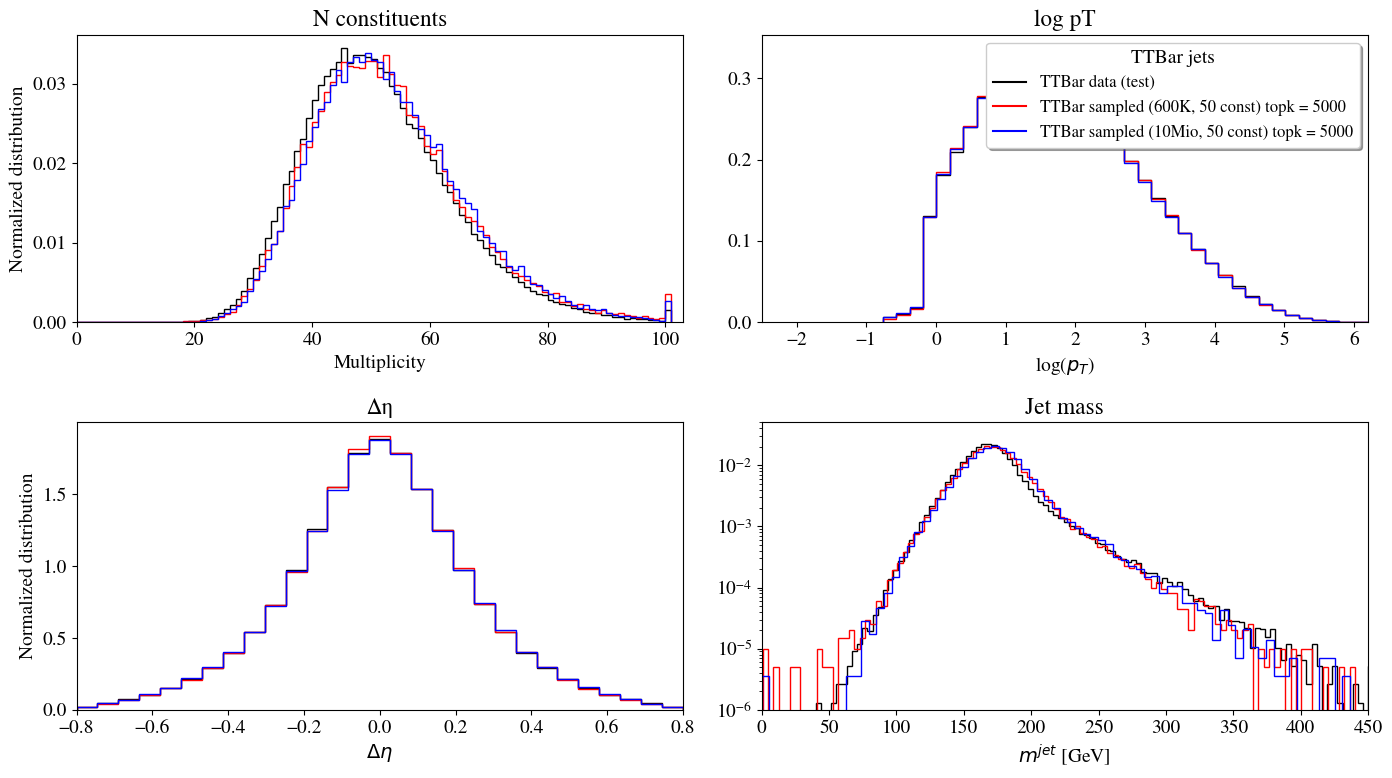

In [31]:

fig, ax = plt.subplots(2,2, figsize=(14,8))

for name, d in processed.items():
    
    ax[0,0].hist(
        d["n_const"],
        bins=101,
        range=(0,101),
        histtype="step",
        density=True,
        #label=name,
        color=d["color"],
        linestyle=d["linestyle"],
    )
    #just for labeling purposes
    ax[0,1].plot(-5,0, color=d["color"], label=name, linestyle = d["linestyle"])

    ax[0,1].hist(
        d["logpt"].flatten(),
        bins=39,
        range=(pt_edges.min(), pt_edges.max()),
        histtype="step",
        density=True,
        color=d["color"],
        linestyle= d["linestyle"]
    )

    ax[1,0].hist(
        d["eta"].flatten(),
        bins=29,
        range=(eta_edges.min(), eta_edges.max()),
        histtype="step",
        density=True,
        color=d["color"],
        linestyle= d["linestyle"]
    )

    ax[1,1].hist(
        d["mass"],
        bins=110,
        histtype="step",
        density=True,
        color=d["color"],
        linestyle= d["linestyle"]
    )

ax[0,0].set_title("N constituents")
ax[0,1].set_title("log pT")
ax[1,0].set_title("Δη")
ax[1,1].set_title("Jet mass")

ax[0,0].set_xlabel("Multiplicity")
ax[0,1].set_xlabel(r"log($p_T$)")
ax[1,0].set_xlabel(r"$\Delta \eta$")
ax[1,1].set_xlabel(r"$m^{jet}$ [GeV]")

ax[1,1].set_yscale("log")

ax[0,0].set_ylabel("Normalized distribution")
ax[1,0].set_ylabel("Normalized distribution")

ax[0,0].set_xlim(0,103)
ax[0,1].set_xlim(-2.5,6.2)
ax[1,0].set_xlim(-0.8,0.8)
ax[1,1].set_xlim(0,450)

ax[1,1].set_ylim(10**(-6),5*10**(-2))

ax[1,0].set_xticks(np.linspace(-0.8,0.8,9))

ax[0,1].legend(loc="upper right", title="TTBar jets", shadow=True, fontsize=12)

plt.tight_layout()
plt.show()

## Plot distributions